#  CNN + FastText — Analyse de Sentiment Darija / Arabizi


##  1. Installation & Imports

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ar.300.bin.gz
!gunzip cc.ar.300.bin.gz

In [ ]:
# Installation des dépendances
!pip install -q fasttext-wheel emoji scikit-learn seaborn matplotlib gensim

# TensorFlow/Keras est déjà disponible sur Colab
# Si nécessaire : !pip install -q tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 19.5 MB/s eta 0:00:00


In [ ]:
import re
import os
import random
import time

import numpy as np
import pandas as pd
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ── Keras / TensorFlow ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# ── Reproductibilité ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f" TensorFlow version : {tf.__version__}")
print(f" Keras version      : {keras.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f" GPU disponible     : {len(gpus) > 0}  {gpus}")


✅ TensorFlow version : 2.20.0
✅ Keras version      : 3.13.2
✅ GPU disponible     : False  []


##  2. Configuration Globale

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION GLOBALE
#  Modifier uniquement cette cellule — tout le reste utilise CFG automatiquement
# ══════════════════════════════════════════════════════════════════════════════

CFG = {
    # ── Données ───────────────────────────────────────────────────────────────

    'base_path' : '/content/drive/MyDrive/analyse_de_sentiments',
    'data_path' : '/content/drive/MyDrive/analyse_de_sentiments/dataset_preprocessed.csv',
    'text_col'       : 'texte',
    'label_col'      : 'label',
    'num_classes'    : 3,
    'label_names'    : ['Negative', 'Neutral', 'Positive'],
    'label_map'      : {'Negative': 0, 'Neutral': 1, 'Positive': 2},

    # ── Mode Emojis ───────────────────────────────────────────────────────────
    #  'keep'               → conservés tels quels
    #  'replace_sentiment'  → __POS__ / __NEG__ / __NEUTRAL__
    #  'remove'             → supprimés
    'emoji_mode'     : 'replace_sentiment',

    # ── Tokenisation / Vocabulaire ────────────────────────────────────────────
    'max_len'        : 100,
    'vocab_size'     : 50_000,
    'min_freq'       : 2,

    # ── Embeddings FastText ───────────────────────────────────────────────────
    #  Télécharger : https://fasttext.cc/docs/en/crawl-vectors.html
    #  Recommandé  : cc.ar.300.bin (arabe) ou cc.fr.300.bin (français)
    'fasttext_path'  : '/content/drive/MyDrive/analyse_de_sentiments/cc.ar.300.bin',
    'embed_dim'      : 300,
    'freeze_embeds'  : False,  # False = fine-tuning des embeddings

    # ── Architecture TextCNN ──────────────────────────────────────────────────
    'kernel_sizes'   : [2, 3, 4, 5],  # capture bi/tri/4/5-grams
    'num_filters'    : 128,
    'dropout'        : 0.5,

    # ── Entraînement ──────────────────────────────────────────────────────────
    'epochs'         : 30,
    'batch_size'     : 64,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,      # régularisation L2 sur la couche Dense
    'patience'       : 5,         # early stopping
    'lr_patience'    : 3,         # réduire LR si plateau
    'lr_factor'      : 0.5,
    'val_size'       : 0.15,
    'test_size'      : 0.15,
}

print('✅ Configuration chargée :')
for k, v in CFG.items():
    print(f'   {k:<20} : {v}')


✅ Configuration chargée :
   base_path            : /content/drive/MyDrive/analyse_de_sentiments
   data_path            : /content/drive/MyDrive/analyse_de_sentiments/dataset_preprocessed.csv
   text_col             : texte
   label_col            : label
   num_classes          : 3
   label_names          : ['Negative', 'Neutral', 'Positive']
   label_map            : {'Negative': 0, 'Neutral': 1, 'Positive': 2}
   emoji_mode           : replace_sentiment
   max_len              : 100
   vocab_size           : 50000
   min_freq             : 2
   fasttext_path        : /content/drive/MyDrive/analyse_de_sentiments/cc.ar.300.bin
   embed_dim            : 300
   freeze_embeds        : False
   kernel_sizes         : [2, 3, 4, 5]
   num_filters          : 128
   dropout              : 0.5
   epochs               : 30
   batch_size           : 64
   lr                   : 0.001
   weight_decay         : 0.0001
   patience             : 5
   lr_patience          : 3
   lr_factor           

##  3. Prétraitement Texte




In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  3.1 — GESTION DES EMOJIS
# ══════════════════════════════════════════════════════════════════════════════

# Dictionnaire de polarité des emojis les plus fréquents en Darija
EMOJI_POLARITY = {
    # Positifs ────────────────────────────────────────────────────────────────
    '😊':'__POS__', '😁':'__POS__', '😄':'__POS__', '😃':'__POS__',
    '😍':'__POS__', '🥰':'__POS__', '😎':'__POS__', '🤩':'__POS__',
    '👍':'__POS__', '❤️':'__POS__', '♥️':'__POS__', '💕':'__POS__',
    '💯':'__POS__', '🙌':'__POS__', '✅':'__POS__', '🎉':'__POS__',
    '🥳':'__POS__', '😂':'__POS__', '🤣':'__POS__', '😆':'__POS__',
    '💪':'__POS__', '🙏':'__POS__', '🌟':'__POS__', '⭐':'__POS__',
    '🔥':'__POS__', '✨':'__POS__', '🌹':'__POS__', '🌺':'__POS__',
    # Négatifs ────────────────────────────────────────────────────────────────
    '😢':'__NEG__', '😭':'__NEG__', '😠':'__NEG__', '😡':'__NEG__',
    '🤬':'__NEG__', '😤':'__NEG__', '😔':'__NEG__', '😞':'__NEG__',
    '👎':'__NEG__', '💔':'__NEG__', '🤮':'__NEG__', '🤢':'__NEG__',
    '😱':'__NEG__', '😰':'__NEG__', '😩':'__NEG__', '😫':'__NEG__',
    '🙄':'__NEG__', '😒':'__NEG__', '😑':'__NEG__', '🥺':'__NEG__',
    # Neutres ─────────────────────────────────────────────────────────────────
    '🤔':'__NEUTRAL__', '😐':'__NEUTRAL__', '😶':'__NEUTRAL__',
    '🤷':'__NEUTRAL__', '🙃':'__NEUTRAL__', '😏':'__NEUTRAL__',
    'ℹ️':'__NEUTRAL__', '📌':'__NEUTRAL__', '📢':'__NEUTRAL__',
}


def handle_emoji(text: str, mode: str = None) -> str:
    """
    Traite les emojis selon le mode choisi dans CFG.

    Modes :
      'keep'               → emojis conservés tels quels
      'replace_sentiment'  → remplacés par __POS__ / __NEG__ / __NEUTRAL__
      'remove'             → supprimés complètement
    """
    mode = mode or CFG['emoji_mode']
    text = str(text)

    if mode == 'keep':
        return text

    elif mode == 'replace_sentiment':
        # Remplacement des emojis connus en premier
        for em, tag in EMOJI_POLARITY.items():
            text = text.replace(em, f' {tag} ')
        # Emojis non répertoriés → __NEUTRAL__ par défaut
        for item in emoji.emoji_list(text):
            text = text.replace(item['emoji'], ' __NEUTRAL__ ')
        return re.sub(r'\s+', ' ', text).strip()

    elif mode == 'remove':
        return re.sub(r'\s+', ' ', emoji.replace_emoji(text, replace='')).strip()

    else:
        raise ValueError(
            f"Mode emoji inconnu : '{mode}'. "
            "Valeurs acceptées : 'keep' | 'replace_sentiment' | 'remove'"
        )


In [ ]:


# Motif commun : lettre arabe ou latine à gauche OU à droite du chiffre
_LETTER = r'[a-zA-Z\u0600-\u06FF]'

ARABIZI_MAP = [
    # (pattern, remplacement)
    (rf'(?<={_LETTER})2|2(?={_LETTER})', 'ء'),   # 2 → ء
    (rf'(?<={_LETTER})3|3(?={_LETTER})', 'ع'),   # 3 → ع
    (rf'(?<={_LETTER})5|5(?={_LETTER})', 'خ'),   # 5 → خ
    (rf'(?<={_LETTER})7|7(?={_LETTER})', 'ح'),   # 7 → ح
    (rf'(?<={_LETTER})9|9(?={_LETTER})', 'ق'),   # 9 → ق
]


def transliterate_arabizi(text: str) -> str:
    """Translittère 2→ء, 3→ع, 5→خ, 7→ح, 9→ق uniquement accolés à des lettres."""
    for pattern, replacement in ARABIZI_MAP:
        text = re.sub(pattern, replacement, str(text))
    return text


In [ ]:



def remove_diacritics(text: str) -> str:
    """Supprime les voyelles brèves et signes diacritiques arabes (tashkil)."""
    return re.sub(r'[\u064B-\u065F\u0670\u0640]', '', str(text))


def normalize_arabic(text: str) -> str:
    """Normalise les variantes orthographiques arabes courantes."""
    text = re.sub(r'[إأآا]', 'ا', str(text))   # formes du alef
    text = re.sub(r'ى', 'ي', text)              # alef maqsura → ya
    text = re.sub(r'ؤ', 'و', text)              # waw avec hamza → waw
    text = re.sub(r'ئ', 'ي', text)              # ya avec hamza → ya
    return text


def is_valid(text: str) -> bool:
    """
    Filtre les textes trop courts ou à dominante numérique.
    Retourne False si : moins de 2 mots, ou + de 50 % de chiffres.
    """
    text = str(text).strip()
    if len(text.split()) < 2:
        return False
    digit_ratio = len(re.findall(r'\d', text)) / max(len(text), 1)
    return digit_ratio < 0.5


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  3.4 — PIPELINE COMPLET
# ══════════════════════════════════════════════════════════════════════════════

def full_pipeline(text: str) -> str:
    """
    Pipeline de prétraitement CNN/FastText Darija.

    Étapes (dans l'ordre) :
      1. Emojis   → selon CFG['emoji_mode']
      2. Arabizi  → 2=ء  3=ع  5=خ  7=ح  9=ق  (accolés à des lettres)
      3. Web noise (URLs, @mentions, hashtags, HTML)
      4. Caractères invisibles
      5. Répétitions excessives
      6. Ponctuation
      7. Diacritiques arabes
      8. Normalisation des variantes arabes
    """
    text = handle_emoji(text)
    text = transliterate_arabizi(text)

    text = remove_diacritics(text)
    text = normalize_arabic(text)
    return re.sub(r'\s+', ' ', text).strip()


# ── Vérification visuelle ─────────────────────────────────────────────────────
tests = [
    '3ndek 7a9 😍 wach kayn l7al?',           # 3 → ع, 7 → ح
    'ماعجبنيش هاد المنتوج 😠👎',               # arabe pur + emojis négatifs
    'kl2a daba machi mezyan !!!!!',            # 2 → ء, ponctuation répétée
    'l9ite chi 7aja zwina bzzaf 💯',            # 9 → ق, 7 → ح
    'had lkitab 5ayb bzzaf 😡',                # 5 → خ  (nouveau)
    'machi mezyan wla khayeb, kaml normal',    # texte neutre sans chiffres
]

print(f'Mode emoji : [{CFG["emoji_mode"]}]\n')
print(f'{"Avant":<50} → Après')
print('-' * 90)
for t in tests:
    print(f'{t:<50} → {full_pipeline(t)}')


Mode emoji : [replace_sentiment]

Avant                                              → Après
------------------------------------------------------------------------------------------
3ndek 7a9 😍 wach kayn l7al?                        → عndek حaق __POS__ wach kayn lحal?
ماعجبنيش هاد المنتوج 😠👎                            → ماعجبنيش هاد المنتوج __NEG__ __NEG__
kl2a daba machi mezyan !!!!!                       → klءa daba machi mezyan !!!!!
l9ite chi 7aja zwina bzzaf 💯                       → lقite chi حaja zwina bzzaf __POS__
had lkitab 5ayb bzzaf 😡                            → had lkitab خayb bzzaf __NEG__
machi mezyan wla khayeb, kaml normal               → machi mezyan wla khayeb, kaml normal


##  4. Chargement & Préparation du Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(CFG['data_path'])
print(f'Shape brut : {df.shape}')
print(f'Colonnes   : {df.columns.tolist()}')
df.head(3)


Mounted at /content/drive
Shape brut : (39834, 2)
Colonnes   : ['texte', 'label']


,texte,label
0,ماكينة عجباتني كاتحيد شعر من الجدر ومكاتخليش ل...,Positive
1,واعرة كاتشد الشارج لمدة طويلة وساهلة فالخدمة ...,Positive
2,زوينة وصغيرة ومطيورة كيما كايقولو هههه، فلوسها...,Positive


In [ ]:
# ── Application du pipeline de prétraitement ──────────────────────────────────
df['text_clean'] = df[CFG['text_col']].apply(full_pipeline)

# ── Encodage des labels en entiers ───────────────────────────────────────────
df['label_id'] = df[CFG['label_col']].map(CFG['label_map'])

# ── Filtrage des lignes invalides ─────────────────────────────────────────────
df = df.dropna(subset=['text_clean', 'label_id'])
df = df[df['text_clean'].apply(is_valid)].reset_index(drop=True)
df['label_id'] = df['label_id'].astype(int)

print(f'Shape après nettoyage : {df.shape}')
print(f'\nDistribution des classes :')
print(
    df['label_id']
    .value_counts()
    .sort_index()
    .rename(index={i: n for i, n in enumerate(CFG['label_names'])})
)


Shape après nettoyage : (39562, 4)

Distribution des classes :
label_id
Negative    15665
Neutral      7495
Positive    16402
Name: count, dtype: int64


##  5. Analyse du Déséquilibre & Class Weights




  ⚠️  DÉSÉQUILIBRE DES CLASSES DÉTECTÉ
  Negative     (id=0):  15665  ( 39.6%)  ███████████████
  Neutral      (id=1):   7495  ( 18.9%)  ███████
  Positive     (id=2):  16402  ( 41.5%)  ████████████████

  Class Weights (balanced) :
    Negative     (id=0) → weight = 0.8418
    Neutral      (id=1) → weight = 1.7595
    Positive     (id=2) → weight = 0.8040


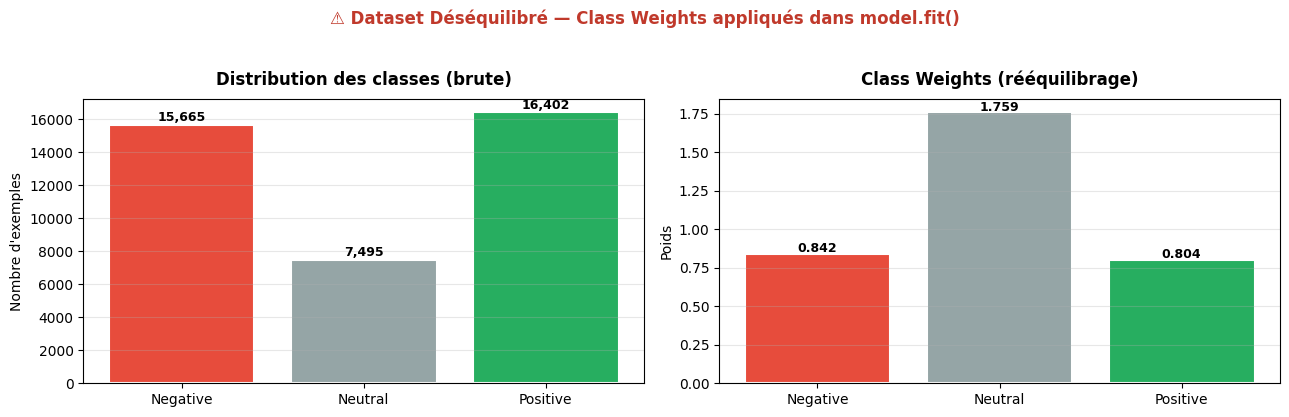

In [ ]:
# ── Distribution brute ───────────────────────────────────────────────────────
counts = df['label_id'].value_counts().sort_index()
total  = len(df)

print('=' * 58)
print('  ⚠️  DÉSÉQUILIBRE DES CLASSES DÉTECTÉ')
print('=' * 58)
for idx, cnt in counts.items():
    name = CFG['label_names'][idx]
    bar  = '█' * int(cnt / total * 40)
    print(f'  {name:<12} (id={idx}): {cnt:>6}  ({cnt/total*100:5.1f}%)  {bar}')

# ── Calcul des class weights (méthode sklearn 'balanced') ────────────────────
classes = np.array(sorted(df['label_id'].unique()))
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df['label_id'].values
)

# Keras attend un dict {class_id: weight}
class_weights_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print(f'\n  Class Weights (balanced) :')
for cid, w in class_weights_dict.items():
    print(f'    {CFG["label_names"][cid]:<12} (id={cid}) → weight = {w:.4f}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#e74c3c', '#95a5a6', '#27ae60']
names  = CFG['label_names']

axes[0].bar(names, [counts.get(i, 0) for i in range(3)], color=colors, edgecolor='white', lw=1.5)
axes[0].set_title('Distribution des classes (brute)', fontweight='bold', pad=10)
axes[0].set_ylabel("Nombre d'exemples")
for i, v in enumerate([counts.get(j, 0) for j in range(3)]):
    axes[0].text(i, v + total * 0.005, f'{v:,}', ha='center', fontweight='bold', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(names, [class_weights_dict[i] for i in range(3)], color=colors, edgecolor='white', lw=1.5)
axes[1].set_title('Class Weights (rééquilibrage)', fontweight='bold', pad=10)
axes[1].set_ylabel('Poids')
for i in range(3):
    w = class_weights_dict[i]
    axes[1].text(i, w + 0.01, f'{w:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    '⚠️ Dataset Déséquilibré — Class Weights appliqués dans model.fit()',
    fontsize=12, fontweight='bold', y=1.03, color='#c0392b'
)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


##  6. Vocabulaire & Tokenisation

In [ ]:
# Tokens spéciaux réservés
PAD_TOKEN = '<PAD>'   # index 0  — utilisé pour le padding
UNK_TOKEN = '<UNK>'   # index 1  — token hors-vocabulaire


def tokenize(text: str) -> list:
    """Tokenisation par espaces, adaptée au Darija/Arabizi mélangé."""
    return str(text).strip().split()


class Vocabulary:
    """
    Construit un vocabulaire à partir d'une liste de textes.

    Attributs :
      word2idx  : dict {token → indice entier}
      idx2word  : dict {indice entier → token}
      min_freq  : fréquence minimale pour inclure un token
      max_size  : taille maximale du vocabulaire (hors tokens spéciaux)
    """

    def __init__(self, min_freq: int = 2, max_size: int = 50_000):
        self.min_freq = min_freq
        self.max_size = max_size
        # PAD=0 et UNK=1 sont toujours présents
        self.word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
        self.idx2word = {0: PAD_TOKEN, 1: UNK_TOKEN}

    def build(self, texts: list) -> 'Vocabulary':
        """Construit le vocabulaire depuis une liste de textes pré-traités."""
        counter = Counter(tok for text in texts for tok in tokenize(text))
        # Garder les max_size tokens les plus fréquents avec freq ≥ min_freq
        vocab_tokens = [
            w for w, c in counter.most_common(self.max_size)
            if c >= self.min_freq
        ]
        for word in vocab_tokens:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word

        print(
            f'✅ Vocabulaire construit : {len(self.word2idx):,} tokens '
            f'(min_freq={self.min_freq}, max_size={self.max_size})'
        )
        return self

    def encode(self, text: str, max_len: int) -> list:
        """
        Convertit un texte en liste d'indices entiers de longueur max_len.
        - Troncature à droite si trop long
        - Padding (indice 0) à droite si trop court
        - Tokens inconnus → indice 1 (UNK)
        """
        tokens = tokenize(text)[:max_len]
        ids    = [self.word2idx.get(t, 1) for t in tokens]
        ids   += [0] * (max_len - len(ids))   # padding à droite
        return ids

    def __len__(self) -> int:
        return len(self.word2idx)


# ── Construction du vocabulaire ───────────────────────────────────────────────
vocab = Vocabulary(min_freq=CFG['min_freq'], max_size=CFG['vocab_size'])
vocab.build(df['text_clean'])

# ── Taux OOV (out-of-vocabulary) ─────────────────────────────────────────────
all_tokens = [t for text in df['text_clean'] for t in tokenize(text)]
oov_count  = sum(1 for t in all_tokens if t not in vocab.word2idx)
print(f'   OOV rate  : {oov_count / len(all_tokens) * 100:.2f}%')
print(f'   Total tokens dans le corpus : {len(all_tokens):,}')


✅ Vocabulaire construit : 35,164 tokens (min_freq=2, max_size=50000)
   OOV rate  : 14.95%
   Total tokens dans le corpus : 546,560


##  7. Chargement des Embeddings FastText

In [ ]:
def build_embedding_matrix(vocab: Vocabulary, ft_model, embed_dim: int) -> np.ndarray:
    """
    Construit la matrice d'embeddings de forme (vocab_size, embed_dim).

    - PAD (index 0)       → vecteur zéro (ne contribue pas au calcul)
    - Tokens connus       → vecteur FastText (gère les OOV via sous-mots)
    - Tokens non trouvés  → initialisation uniforme aléatoire [-0.25, 0.25]
    """
    V      = len(vocab)
    matrix = np.zeros((V, embed_dim), dtype=np.float32)

    found, total = 0, 0
    for word, idx in vocab.word2idx.items():
        if word == PAD_TOKEN:
            continue   # laisser le vecteur zéro pour PAD
        total += 1
        try:
            vec = ft_model.get_word_vector(word)   # FastText gère les OOV
            matrix[idx] = vec
            found += 1
        except Exception:
            # Initialisation aléatoire pour les tokens inconnus
            matrix[idx] = np.random.uniform(-0.25, 0.25, embed_dim)

    coverage = found / max(total, 1) * 100
    print(
        f'✅ Embeddings construits : {found}/{total} tokens '
        f'couverts par FastText ({coverage:.1f}%)'
    )
    return matrix


# ── Chargement du modèle FastText ─────────────────────────────────────────────
try:
    import fasttext
    print('Chargement FastText... (peut prendre 1-2 min)')
    ft_model = fasttext.load_model(CFG['fasttext_path'])
    embedding_matrix = build_embedding_matrix(vocab, ft_model, CFG['embed_dim'])
    print(f'   Shape de la matrice : {embedding_matrix.shape}')

except Exception as e:
    print(f'⚠️  FastText non disponible ({e})')
    print('   → Fallback : embeddings aléatoires (à remplacer en production)')
    V = len(vocab)
    embedding_matrix = np.random.uniform(
        -0.25, 0.25, (V, CFG['embed_dim'])
    ).astype(np.float32)
    embedding_matrix[0] = 0.0   # PAD = vecteur zéro
    print(f'   Shape de la matrice : {embedding_matrix.shape}')


Chargement FastText... (peut prendre 1-2 min)
⚠️  FastText non disponible (/content/drive/MyDrive/analyse_de_sentiments/cc.ar.300.bin cannot be opened for loading!)
   → Fallback : embeddings aléatoires (à remplacer en production)


   Shape de la matrice : (35164, 300)


## 8. Préparation des Données (Arrays NumPy + Split)

In [ ]:
# ── Encodage de tous les textes en matrices entières ─────────────────────────
MAX_LEN = CFG['max_len']

X_all = np.array(
    [vocab.encode(t, MAX_LEN) for t in df['text_clean']],
    dtype=np.int32
)
y_all = df['label_id'].values.astype(np.int32)

# ── Split stratifié train / val / test ───────────────────────────────────────
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_all, y_all,
    test_size=CFG['test_size'],
    random_state=SEED,
    stratify=y_all
)

val_ratio = CFG['val_size'] / (1 - CFG['test_size'])
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y_tmp
)

print('✅ Split stratifié :')
print(f'   Train : {len(X_train):>6}  |  Val : {len(X_val):>6}  |  Test : {len(X_test):>6}')
print(f'   X_train shape : {X_train.shape}')
print(f'   X_test  shape : {X_test.shape}')

# Conserver les textes bruts pour l'analyse d'erreurs (section 14)
texts_all  = df['text_clean'].tolist()
_, X_test_texts, _, _ = train_test_split(
    texts_all, y_all,
    test_size=CFG['test_size'],
    random_state=SEED,
    stratify=y_all
)


✅ Split stratifié :
   Train :  27692  |  Val :   5935  |  Test :   5935
   X_train shape : (27692, 100)
   X_test  shape : (5935, 100)


## 9. Architecture TextCNN



In [ ]:
def build_textcnn(
    vocab_size    : int,
    embed_dim     : int,
    num_classes   : int,
    kernel_sizes  : list,
    num_filters   : int,
    dropout_rate  : float,
    embed_matrix  : np.ndarray = None,
    freeze_embeds : bool = False,
    weight_decay  : float = 1e-4,
) -> keras.Model:
    """
    Construit un modèle TextCNN multi-kernel avec Keras Functional API.

    Inspiré de Kim (2014) 'Convolutional Neural Networks for Sentence Classification'.

    Paramètres
    ----------
    vocab_size    : taille du vocabulaire (incluant PAD et UNK)
    embed_dim     : dimension des embeddings FastText (300)
    num_classes   : nombre de classes de sortie (3)
    kernel_sizes  : liste des tailles de filtres convolutifs ex: [2, 3, 4, 5]
    num_filters   : nombre de filtres par taille de kernel
    dropout_rate  : taux de dropout après la concaténation
    embed_matrix  : matrice pré-entraînée (numpy array), None → random
    freeze_embeds : si True, l'embedding layer n'est pas entraînable
    weight_decay  : régularisation L2 sur la couche Dense finale
    """

    # ── Entrée ────────────────────────────────────────────────────────────────
    inputs = keras.Input(shape=(CFG['max_len'],), dtype='int32', name='token_ids')

    # ── Embedding layer ───────────────────────────────────────────────────────
    # mask_zero=False car GlobalMaxPooling1D ne supporte pas le masking
    if embed_matrix is not None:
        embedding_layer = layers.Embedding(
            input_dim    = vocab_size,
            output_dim   = embed_dim,
            embeddings_initializer = keras.initializers.Constant(embed_matrix),
            trainable    = not freeze_embeds,
            mask_zero    = False,
            name         = 'fasttext_embedding'
        )
    else:
        embedding_layer = layers.Embedding(
            input_dim  = vocab_size,
            output_dim = embed_dim,
            trainable  = not freeze_embeds,
            mask_zero  = False,
            name       = 'random_embedding'
        )

    x = embedding_layer(inputs)   # (batch, max_len, embed_dim)

    # ── Blocs convolutifs parallèles (un par taille de kernel) ───────────────
    pooled_outputs = []
    for k in kernel_sizes:
        # Conv1D attend (batch, steps, features)
        conv = layers.Conv1D(
            filters     = num_filters,
            kernel_size = k,
            padding     = 'valid',
            name        = f'conv1d_k{k}'
        )(x)
        norm = layers.BatchNormalization(name=f'bn_k{k}')(conv)
        relu = layers.Activation('relu', name=f'relu_k{k}')(norm)
        pool = layers.GlobalMaxPooling1D(name=f'maxpool_k{k}')(relu)  # max-over-time
        pooled_outputs.append(pool)

    # ── Concaténation de toutes les features ─────────────────────────────────
    if len(pooled_outputs) > 1:
        concat = layers.Concatenate(name='concat')(pooled_outputs)  # (batch, num_filters * len(kernel_sizes))
    else:
        concat = pooled_outputs[0]

    # ── Régularisation ────────────────────────────────────────────────────────
    dropped = layers.Dropout(dropout_rate, name='dropout')(concat)

    # ── Classification ────────────────────────────────────────────────────────
    outputs = layers.Dense(
        num_classes,
        activation           = 'softmax',
        kernel_regularizer   = regularizers.l2(weight_decay),
        kernel_initializer   = 'glorot_uniform',
        name                 = 'classifier'
    )(dropped)

    model = keras.Model(inputs=inputs, outputs=outputs, name='TextCNN_Darija')
    return model


# ── Instanciation du modèle ───────────────────────────────────────────────────
model = build_textcnn(
    vocab_size    = len(vocab),
    embed_dim     = CFG['embed_dim'],
    num_classes   = CFG['num_classes'],
    kernel_sizes  = CFG['kernel_sizes'],
    num_filters   = CFG['num_filters'],
    dropout_rate  = CFG['dropout'],
    embed_matrix  = embedding_matrix,
    freeze_embeds = CFG['freeze_embeds'],
    weight_decay  = CFG['weight_decay'],
)

# ── Compilation ───────────────────────────────────────────────────────────────
# sparse_categorical_crossentropy car les labels sont des entiers (pas one-hot)
model.compile(
    optimizer = optimizers.Adam(learning_rate=CFG['lr']),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Résumé ────────────────────────────────────────────────────────────────────
model.summary(expand_nested=True)
print(f'\n  Kernels         : {CFG["kernel_sizes"]}')
print(f'  Filtres/kernel  : {CFG["num_filters"]}')
print(f'  Embedding dim   : {CFG["embed_dim"]}  (freeze={CFG["freeze_embeds"]})')
print(f'  Dropout         : {CFG["dropout"]}')


Model: "TextCNN_Darija"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fasttext_embedding  │ (None, 100, 300)  │ 10,549,200 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k2 (Conv1D)  │ (None, 99, 128)   │     76,928 │ fasttext_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k3 (Conv1D)  │ (None, 98, 128)   │    115,328 │ fasttext_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k4 (Conv1D)  │ (None, 97, 128)   │    153,728 │ fasttext_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k5 (Conv1D)  │ (None, 96, 128)   │    192,128 │ fasttext_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k2               │ (None, 99, 128)   │        512 │ conv1d_k2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k3               │ (None, 98, 128)   │        512 │ conv1d_k3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k4               │ (None, 97, 128)   │        512 │ conv1d_k4[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_k5               │ (None, 96, 128)   │        512 │ conv1d_k5[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_k2             │ (None, 99, 128)   │          0 │ bn_k2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_k3             │ (None, 98, 128)   │          0 │ bn_k3[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_k4             │ (None, 97, 128)   │          0 │ bn_k4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_k5             │ (None, 96, 128)   │          0 │ bn_k5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_k2          │ (None, 128)       │          0 │ relu_k2[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_k3          │ (None, 128)       │          0 │ relu_k3[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_k4          │ (None, 128)       │          0 │ relu_k4[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_k5          │ (None, 128)       │          0 │ relu_k5[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                 

 Total params: 11,090,899 (42.31 MB)

 Trainable params: 11,089,875 (42.30 MB)

 Non-trainable params: 1,024 (4.00 KB)


  Kernels         : [2, 3, 4, 5]
  Filtres/kernel  : 128
  Embedding dim   : 300  (freeze=False)
  Dropout         : 0.5


## 10. Entraînement + Early Stopping + ReduceLROnPlateau

In [ ]:
# ── Callbacks ─────────────────────────────────────────────────────────────────

# EarlyStopping : surveille val_loss, restaure les meilleurs poids automatiquement
early_stop = callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = CFG['patience'],
    restore_best_weights = True,   # restaure les poids du meilleur epoch
    verbose              = 1
)

# ReduceLROnPlateau : divise le LR par lr_factor si val_loss stagne
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = CFG['lr_factor'],
    patience = CFG['lr_patience'],
    verbose  = 1,
    min_lr   = 1e-6
)

# ModelCheckpoint : sauvegarde le meilleur modèle sur disque
checkpoint = callbacks.ModelCheckpoint(
    filepath           = 'best_textcnn_darija.keras',
    monitor            = 'val_loss',
    save_best_only     = True,
    save_weights_only  = False,
    verbose            = 0
)

# ── Entraînement ──────────────────────────────────────────────────────────────
print('=' * 72)
print(f'  ENTRAÎNEMENT — {CFG["epochs"]} epochs max  |  '
      f'Early Stopping patience={CFG["patience"]}')
print(f'  Loss : sparse_categorical_crossentropy + class_weight')
print(f'  Class weights : {class_weights_dict}')
print('=' * 72)

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = CFG['epochs'],
    batch_size      = CFG['batch_size'],
    class_weight    = class_weights_dict,   # ⚠️ gestion du déséquilibre
    callbacks       = [early_stop, reduce_lr, checkpoint],
    verbose         = 1
)

print(f'\n✅ Entraînement terminé ({len(history.history["loss"])} epochs)')
print(f'✅ Meilleur modèle sauvegardé : best_textcnn_darija.keras')


  ENTRAÎNEMENT — 30 epochs max  |  Early Stopping patience=5
  Loss : sparse_categorical_crossentropy + class_weight
  Class weights : {0: 0.8418342376848601, 1: 1.759484100511452, 2: 0.8040076413445515}
Epoch 1/30
433/433 ━━━━━━━━━━━━━━━━━━━━ 329s 748ms/step - accuracy: 0.7016 - loss: 1.2049 - val_accuracy: 0.7754 - val_loss: 0.5339 - learning_rate: 0.0010
Epoch 2/30
433/433 ━━━━━━━━━━━━━━━━━━━━ 321s 741ms/step - accuracy: 0.8349 - loss: 0.4157 - val_accuracy: 0.8155 - val_loss: 0.4558 - learning_rate: 0.0010
Epoch 3/30
433/433 ━━━━━━━━━━━━━━━━━━━━ 296s 683ms/step - accuracy: 0.9111 - loss: 0.2351 - val_accuracy: 0.8243 - val_loss: 0.4558 - learning_rate: 0.0010
Epoch 4/30
433/433 ━━━━━━━━━━━━━━━━━━━━ 295s 682ms/step - accuracy: 0.9470 - loss: 0.1511 - val_accuracy: 0.8204 - val_loss: 0.5016 - learning_rate: 0.0010
Epoch 5/30
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9554 - loss: 0.1261
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
433/433 

## 11. Courbes d'Entraînement

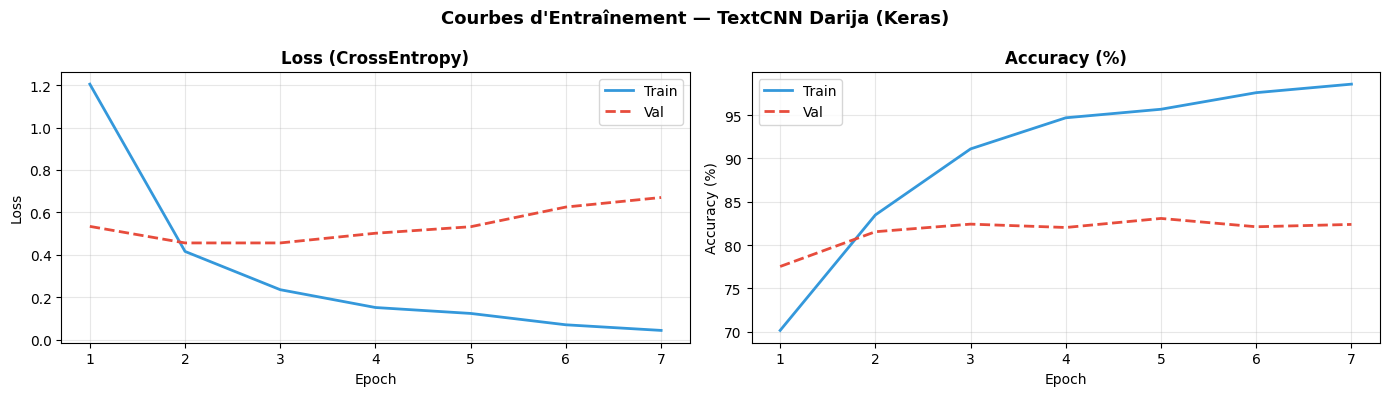

✅ Sauvegardé : training_curves.png


In [ ]:
hist = history.history
epochs_ran = len(hist['loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Courbes d'Entraînement — TextCNN Darija (Keras)", fontsize=13, fontweight='bold')

# ── Loss ──────────────────────────────────────────────────────────────────────
axes[0].plot(ep_range, hist['loss'],     label='Train', color='#3498db', lw=2)
axes[0].plot(ep_range, hist['val_loss'], label='Val',   color='#e74c3c', lw=2, ls='--')
axes[0].set_title('Loss (CrossEntropy)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────────
axes[1].plot(ep_range, [a * 100 for a in hist['accuracy']],
             label='Train', color='#3498db', lw=2)
axes[1].plot(ep_range, [a * 100 for a in hist['val_accuracy']],
             label='Val',   color='#e74c3c', lw=2, ls='--')
axes[1].set_title('Accuracy (%)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sauvegardé : training_curves.png')


##  12. Évaluation Finale sur le Test Set

In [ ]:
# ── Prédictions sur le set de test ───────────────────────────────────────────
# Le modèle a été restauré aux meilleurs poids par EarlyStopping
y_prob  = model.predict(X_test, batch_size=CFG['batch_size'], verbose=0)
y_pred  = y_prob.argmax(axis=1)
y_true  = y_test

# ── Métriques ─────────────────────────────────────────────────────────────────
test_acc = (y_pred == y_true).mean()
test_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 65)
print('  📊 RÉSULTATS FINAUX — SET DE TEST')
print('=' * 65)
print(f'  Accuracy   : {test_acc * 100:.2f}%')
print(f'  F1-macro   : {test_f1 * 100:.2f}%')
print()
print('  Classification Report :')
print('-' * 65)
print(classification_report(
    y_true, y_pred,
    target_names=CFG['label_names'],
    digits=4,
    zero_division=0
))


  📊 RÉSULTATS FINAUX — SET DE TEST
  Accuracy   : 81.42%
  F1-macro   : 80.09%

  Classification Report :
-----------------------------------------------------------------
              precision    recall  f1-score   support

    Negative     0.8832    0.7723    0.8241      2350
     Neutral     0.6310    0.8505    0.7245      1124
    Positive     0.8715    0.8375    0.8541      2461

    accuracy                         0.8142      5935
   macro avg     0.7952    0.8201    0.8009      5935
weighted avg     0.8306    0.8142    0.8177      5935



## 13. Matrice de Confusion

✅ Sauvegardé : confusion_matrix_cnn.png


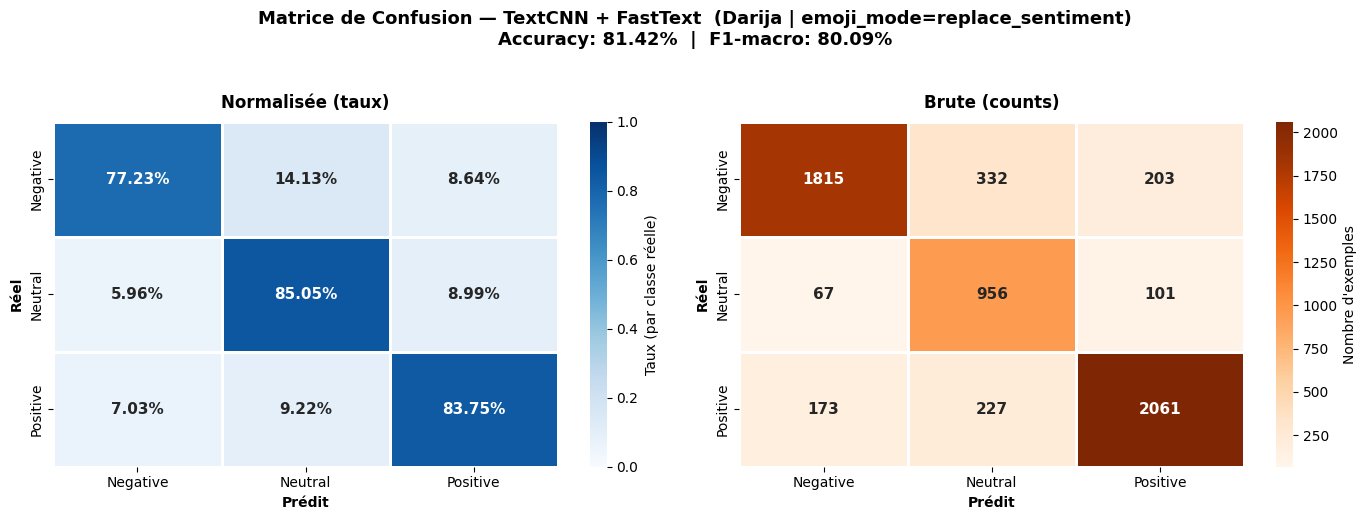

In [ ]:
def plot_confusion_matrix(
    y_true, y_pred, label_names,
    model_name='TextCNN', save_path=None
):
    """
    Affiche deux matrices de confusion côte à côte :
      - Gauche : normalisée (taux par classe réelle)
      - Droite : brute (nombre d'exemples)
    """
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    acc = (np.array(y_pred) == np.array(y_true)).mean() * 100
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Matrice de Confusion — {model_name}\n'
        f'Accuracy: {acc:.2f}%  |  F1-macro: {f1m:.2f}%',
        fontsize=13, fontweight='bold', y=1.03
    )

    # Matrice normalisée
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%',
        cmap='Blues', ax=axes[0],
        xticklabels=label_names, yticklabels=label_names,
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'},
        vmin=0, vmax=1,
        cbar_kws={'label': 'Taux (par classe réelle)'}
    )
    axes[0].set_title('Normalisée (taux)', fontweight='bold', pad=10)
    axes[0].set_xlabel('Prédit',  fontweight='bold')
    axes[0].set_ylabel('Réel',    fontweight='bold')
    axes[0].tick_params(axis='x', rotation=0)

    # Matrice brute
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Oranges', ax=axes[1],
        xticklabels=label_names, yticklabels=label_names,
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 11, 'weight': 'bold'},
        cbar_kws={'label': "Nombre d'exemples"}
    )
    axes[1].set_title('Brute (counts)', fontweight='bold', pad=10)
    axes[1].set_xlabel('Prédit',  fontweight='bold')
    axes[1].set_ylabel('Réel',    fontweight='bold')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'✅ Sauvegardé : {save_path}')
    plt.show()


plot_confusion_matrix(
    y_true, y_pred,
    label_names = CFG['label_names'],
    model_name  = f'TextCNN + FastText  (Darija | emoji_mode={CFG["emoji_mode"]})',
    save_path   = 'confusion_matrix_cnn.png'
)


##  14. Analyse des Erreurs

In [ ]:
id2label = {v: k for k, v in CFG['label_map'].items()}

df_test = pd.DataFrame({
    'texte'   : X_test_texts,
    'vrai'    : [id2label[l] for l in y_true],
    'prédit'  : [id2label[p] for p in y_pred],
    'correct' : [l == p for l, p in zip(y_true, y_pred)]
})

erreurs = df_test[~df_test['correct']].copy()
total_test = len(df_test)

print(f'Erreurs totales : {len(erreurs)} / {total_test}  '
      f'({len(erreurs) / total_test * 100:.1f}%)')
print(f'\nTop confusions (vrai → prédit) :')
print(
    erreurs
    .groupby(['vrai', 'prédit'])
    .size()
    .sort_values(ascending=False)
    .head(6)
)
print(f'\nExemples d\'erreurs :')
print('-' * 80)
for _, row in erreurs.head(10).iterrows():
    print(f'  [{row["vrai"]}] → [{row["prédit"]}]  |  {row["texte"][:70]}')


Erreurs totales : 1103 / 5935  (18.6%)

Top confusions (vrai → prédit) :
vrai      prédit  
Negative  Neutral     332
Positive  Neutral     227
Negative  Positive    203
Positive  Negative    173
Neutral   Positive    101
          Negative     67
dtype: int64

Exemples d'erreurs :
--------------------------------------------------------------------------------
  [Positive] → [Neutral]  |  ZIN ~O TBATA~WLD~SBATA ~O YحAMI 3 http://t.co/aQrDlqQNhT
  [Positive] → [Neutral]  |  @MarouaZahour aaahh fhemt !! la la kolchi ghaydoz mzian, Elie w Ali gh
  [Negative] → [Neutral]  |  @hsinaa bessah hadchi li kayn dok lmourahiقin mataymttlouch fans hanan
  [Positive] → [Negative]  |  قرار بنكيران كان فمحله ، لان القضية خدات بعد سياسي اكثر من انساني وهاد
  [Neutral] → [Positive]  |  @MouhamedFadilou @assanefaall Wakhtane leine rek __POS__ __POS__ xam n
  [Negative] → [Neutral]  |  الناس ديال ارفود الثقة التامة
  [Negative] → [Neutral]  |  @sofia_copola Waaaaحaaamaaaقtili kaari b tweets
  [Positive] 

## 15. Inférence — Prédiction sur Nouveaux Textes

In [ ]:
def predict(texts: list, model: keras.Model, vocab: Vocabulary,
            max_len: int, id2label: dict) -> list:
    """
    Prédit le sentiment de nouveaux textes Darija/Arabizi.

    Paramètres
    ----------
    texts    : liste de textes bruts (non pré-traités)
    model    : modèle Keras entraîné
    vocab    : vocabulaire construit pendant l'entraînement
    max_len  : longueur max de séquence (doit correspondre au modèle)
    id2label : dict {indice → label string}

    Retourne
    --------
    Liste de dicts : texte, texte nettoyé, label prédit, probabilités
    """
    # Pré-traitement identique à celui de l'entraînement
    clean_texts = [full_pipeline(t) for t in texts]

    # Encodage en indices
    X = np.array(
        [vocab.encode(t, max_len) for t in clean_texts],
        dtype=np.int32
    )

    # Inférence
    probs = model.predict(X, verbose=0)   # (n, num_classes)
    preds = probs.argmax(axis=1)

    results = []
    for i, (text, clean) in enumerate(zip(texts, clean_texts)):
        results.append({
            'texte'   : text,
            'nettoyé' : clean,
            'label'   : id2label[preds[i]],
            'probs'   : {
                id2label[j]: float(f'{probs[i][j]:.4f}')
                for j in range(len(id2label))
            }
        })
    return results


# ── Test sur phrases nouvelles ───────────────────────────────────────────────
nouveaux = [
    'هاد المنتوج زوين بزاف 😍💯',
    'ماعجبنيش خالص، ردو ليا الفلوس 😡',
    '3ndek 7a9 hada shi mzyan bzzaf',
    'machi mezyan wla khayeb, kaml normal',
    'l9ite 7aja khdama mezyan, mbruk 🎉',
    'hadchi mazwin makhyb 3adiiii jidaan',           # test chiffre 5 → خ
]

id2label = {v: k for k, v in CFG['label_map'].items()}
results  = predict(nouveaux, model, vocab, CFG['max_len'], id2label)

print('═' * 75)
print('  PRÉDICTIONS SUR NOUVEAUX TEXTES')
print('═' * 75)
for r in results:
    icon = {'Positive': '🟢', 'Neutral': '🟡', 'Negative': '🔴'}.get(r['label'], '⚪')
    prob = r['probs'][r['label']]
    print(f"  {icon} [{r['label']:<10}] ({prob:.0%})  →  {r['texte']}")
    print(
        f"     Probs : "
        f"Neg={r['probs']['Negative']:.2%}  "
        f"Neu={r['probs']['Neutral']:.2%}  "
        f"Pos={r['probs']['Positive']:.2%}"
    )
    print()


═══════════════════════════════════════════════════════════════════════════
  PRÉDICTIONS SUR NOUVEAUX TEXTES
═══════════════════════════════════════════════════════════════════════════
  🟢 [Positive  ] (100%)  →  هاد المنتوج زوين بزاف 😍💯
     Probs : Neg=0.13%  Neu=0.03%  Pos=99.84%

  🔴 [Negative  ] (99%)  →  ماعجبنيش خالص، ردو ليا الفلوس 😡
     Probs : Neg=99.19%  Neu=0.60%  Pos=0.21%

  🟡 [Neutral   ] (63%)  →  3ndek 7a9 hada shi mzyan bzzaf
     Probs : Neg=9.97%  Neu=63.21%  Pos=26.82%

  🟡 [Neutral   ] (71%)  →  machi mezyan wla khayeb, kaml normal
     Probs : Neg=9.99%  Neu=71.13%  Pos=18.88%

  🟢 [Positive  ] (92%)  →  l9ite 7aja khdama mezyan, mbruk 🎉
     Probs : Neg=1.91%  Neu=6.00%  Pos=92.09%

  🟡 [Neutral   ] (44%)  →  hadchi mazwin makhyb 3adiiii jidaan
     Probs : Neg=31.76%  Neu=44.49%  Pos=23.75%

